In [5]:
import sys
import os

# Add parent directory of the notebook to sys.path
sys.path.append(os.path.abspath(".."))

In [6]:
import numpy as np
import pickle as pkl
from plot_params import *
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase



In [7]:
with open('results_pcn.pkl', 'rb') as f:
    results = pkl.load(f)

r2_l = results["r2_l"]
pr_l = results["pr_l"]
train_score_l = results["train_score_l"]
max_move_l = results["max_move_l"]
n_seeds = results["n_seeds"]
train_score_mean = train_score_l.mean(axis=1)
train_score_std = train_score_l.std(axis=1)
r2_mean = r2_l.mean(axis=1)
r2_std = r2_l.std(axis=1)
pr_mean = pr_l.mean(axis=1)
pr_std = pr_l.std(axis=1)

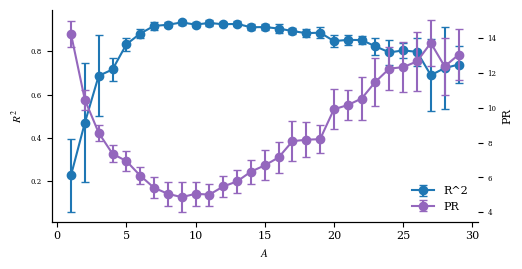

In [18]:
fig, ax1 = plt.subplots(figsize=(FIG_WIDTH, FIG_WIDTH/2))
ax2 = ax1.twinx()

# line_train = ax1.errorbar(
#     max_move_l, train_score_mean, yerr=train_score_std, label="Train Score", marker="o", capsize=3
# )
line_r2 = ax1.errorbar(max_move_l, r2_mean, yerr=r2_std, label="$R^2$", marker="o", capsize=3)
line_pr = ax2.errorbar(max_move_l, pr_mean, yerr=pr_std, label="PR", color="tab:purple", marker="o", capsize=3)

ax1.set_xlabel("$A$")
ax1.set_ylabel("$R^2$")
ax2.set_ylabel("PR")
ax1.legend([line_r2, line_pr], ["R^2", "PR"], loc="best")
fig.savefig("score_vs_max_move.png")
plt.show()

fig.savefig(r'./final_results/figures/fig_pcn.png', dpi=300, bbox_inches='tight')